<a href="https://colab.research.google.com/github/Aarush-Yadavv/Mircosoft_Training/blob/main/Linear_Regression_Assesment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aarush Yadav
# 15/07/2026
# 0827AL221001

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('placement.csv')

In [ ]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [ ]:
df.tail()

,cgpa,package
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96
199,6.22,2.33


In [ ]:
df.shape

(200, 2)

In [ ]:
df.isnull().sum()

,0
cgpa,0
package,0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
195,False
196,False
197,False
198,False


In [ ]:
duplicate_indexes = df[df.duplicated()].index
print(duplicate_indexes)

Index([], dtype='int64')


Text(0, 0.5, 'Package(in lpa)')

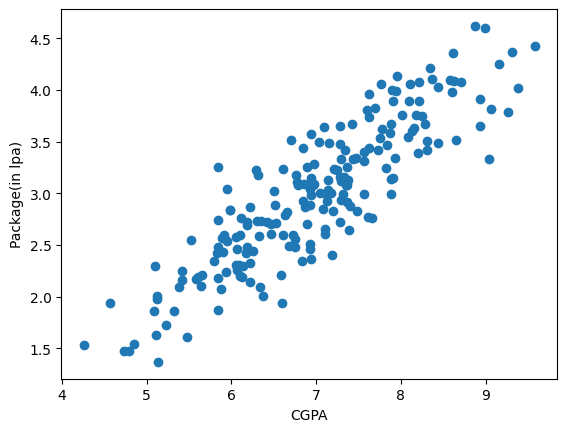

In [ ]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [ ]:
X = df[['cgpa']]
y = df['package']

In [ ]:
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [ ]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (160, 1)
Testing Features Shape: (40, 1)
Training Target Shape: (160,)
Testing Target Shape: (40,)


In [ ]:
algo = LinearRegression()

In [ ]:
algo.fit(X_train,y_train)

LinearRegression()

In [ ]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [ ]:
y_test

,package
112,4.10
29,3.49
182,2.08
199,2.33
193,1.94
85,1.48
10,1.86
54,3.09
115,4.21
35,2.87


In [ ]:
# Select the first student's CGPA from the test dataset
student_cgpa = X_test.iloc[[0]]

# Predict the placement package
predicted_package = algo.predict(student_cgpa)

print("Student CGPA:")
print(student_cgpa)

print("Predicted Package (LPA):", predicted_package[0])

Student CGPA:
     cgpa
112  8.58
Predicted Package (LPA): 3.891116009744203


In [ ]:
y_pred = algo.predict(X_test)

print(y_pred)

[3.89111601 3.09324469 2.38464568 2.57434935 1.6537286  1.77647803
 2.07219258 2.93143862 3.76278706 2.93701814 4.09197872 3.51170867
 2.97049525 2.40138424 3.18809652 3.46707251 1.94386362 3.24389172
 2.97607477 3.41685683 2.55761079 3.16577844 2.85890486 3.12114229
 3.68467378 2.8700639  3.49497011 3.34432308 3.91901361 1.96060218
 3.65119666 3.2104146  3.74046898 2.7863711  2.78079158 3.27178932
 3.52844723 2.61340599 2.65804215 2.71383735]


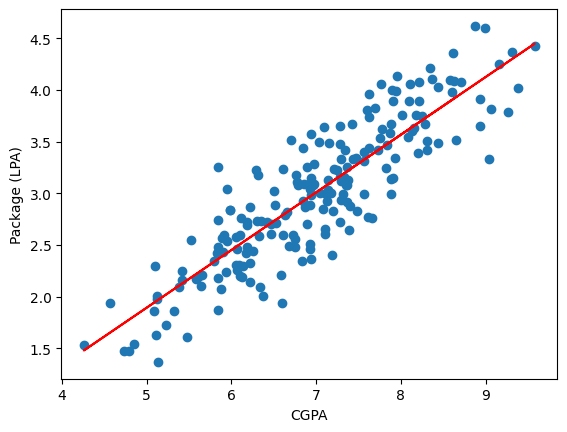

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'], df['package'])

plt.plot(X_train, algo.predict(X_train), color='red')

plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")

plt.show()

In [ ]:
beta1 = algo.coef_
print(beta1)

[0.55795197]


In [ ]:
beta0 = algo.intercept_
print(beta0)

-0.8961119222429144


In [ ]:
beta1 = algo.coef_[0]
beta0 = algo.intercept_

print(f"Equation: Package = {beta1:.2f} × CGPA + {beta0:.2f}")

Equation: Package = 0.56 × CGPA + -0.90


In [ ]:
# y = mx + b

beta1 * 8.58 + beta0

np.float64(3.891116009744203)

In [ ]:
beta1 * 9.5 + beta0

np.float64(4.404431825295269)

In [ ]:
beta1 * 10 + beta0

np.float64(4.683407812007806)

In [ ]:
# Predict all test data
y_pred = algo.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Display Actual, Predicted and Residual values
import pandas as pd

results = pd.DataFrame({
    "Actual Package": y_test.values,
    "Predicted Package": y_pred,
    "Residual": residuals
})

print(results.head())

     Actual Package  Predicted Package  Residual
112            4.10           3.891116  0.208884
29             3.49           3.093245  0.396755
182            2.08           2.384646 -0.304646
199            2.33           2.574349 -0.244349
193            1.94           1.653729  0.286271


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.12129235313495527


In [ ]:
from sklearn.metrics import r2_score

In [ ]:
# Predict the values for the test data
y_pred = algo.predict(X_test)

# Calculate R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.780730147510384
